In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1.LOADING DATA

In [2]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [3]:
df_test_id = pd.DataFrame(df_test['id'])

In [4]:
df_train.drop('id',axis=1,inplace=True)
df_test.drop('id',axis=1,inplace=True)

In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         593994 non-null  float64
 1   debt_to_income_ratio  593994 non-null  float64
 2   credit_score          593994 non-null  int64  
 3   loan_amount           593994 non-null  float64
 4   interest_rate         593994 non-null  float64
 5   gender                593994 non-null  str    
 6   marital_status        593994 non-null  str    
 7   education_level       593994 non-null  str    
 8   employment_status     593994 non-null  str    
 9   loan_purpose          593994 non-null  str    
 10  grade_subgrade        593994 non-null  str    
 11  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(1), str(6)
memory usage: 54.4 MB


## 2.EDA

In [6]:
import math
def plot_all_pie(df,title_prefix=""):
    pie_cols = [col for col in df_train.columns if df_train[col].nunique() <=10]

    n_cols = 3
    n_rows = math.ceil(len(pie_cols) / n_cols)

    plt.figure(figsize=(5*n_cols,5*n_rows))

    for i , col in enumerate(pie_cols,1):
        plt.subplot(n_rows,n_cols,i)
        data = df_train[col].value_counts()

        plt.pie(data,
            labels=data.index,
            autopct = "%1.1f%%",
            startangle=140,
            colors = sns.color_palette('Set3'),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
        plt.title(f"{title_prefix} {col} Distribution",fontsize=12,fontweight='bold')

    plt.tight_layout()
    plt.show()


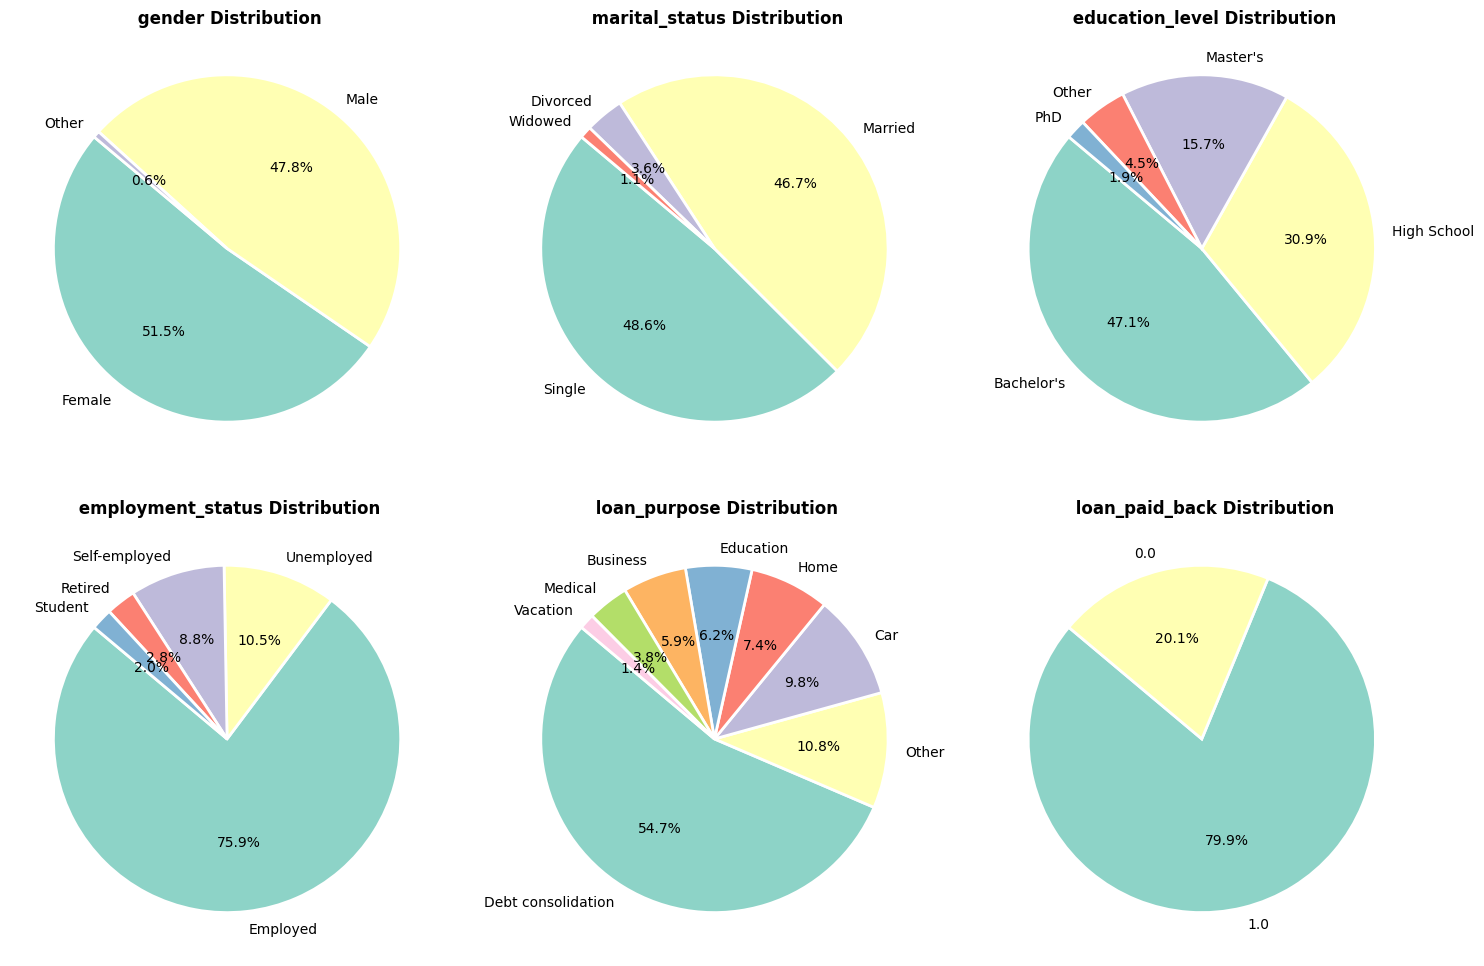

In [7]:
plot_all_pie(df_train)

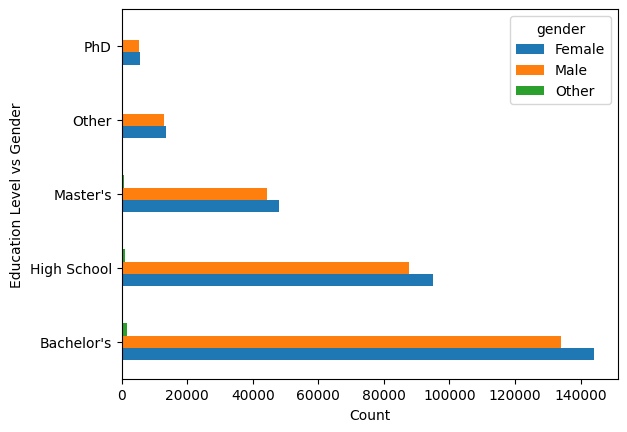

In [8]:
edc_level_gender = df_train.groupby(['education_level','gender']).size().unstack()
edc_level_gender.plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('Education Level vs Gender')

plt.show()

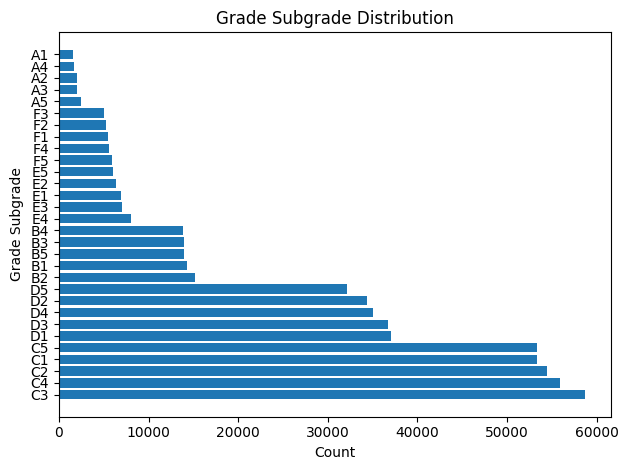

In [9]:
grd_counts = df_train['grade_subgrade'].value_counts()
plt.barh(grd_counts.index,grd_counts.values)
plt.xlabel("Count")
plt.ylabel("Grade Subgrade")
plt.title("Grade Subgrade Distribution")
plt.tight_layout()
plt.show()

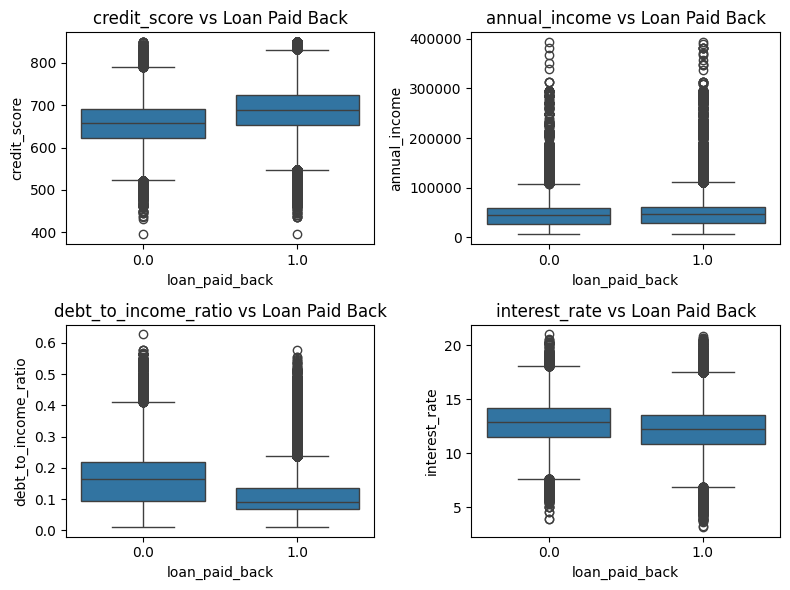

In [10]:
colss = ['credit_score', 'annual_income', 'debt_to_income_ratio', 'interest_rate']
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for ax, col in zip(axes.flatten(), colss):
    sns.boxplot(data=df_train, x='loan_paid_back', y=col, ax=ax)
    ax.set_title(f'{col} vs Loan Paid Back')
plt.tight_layout()
plt.show()

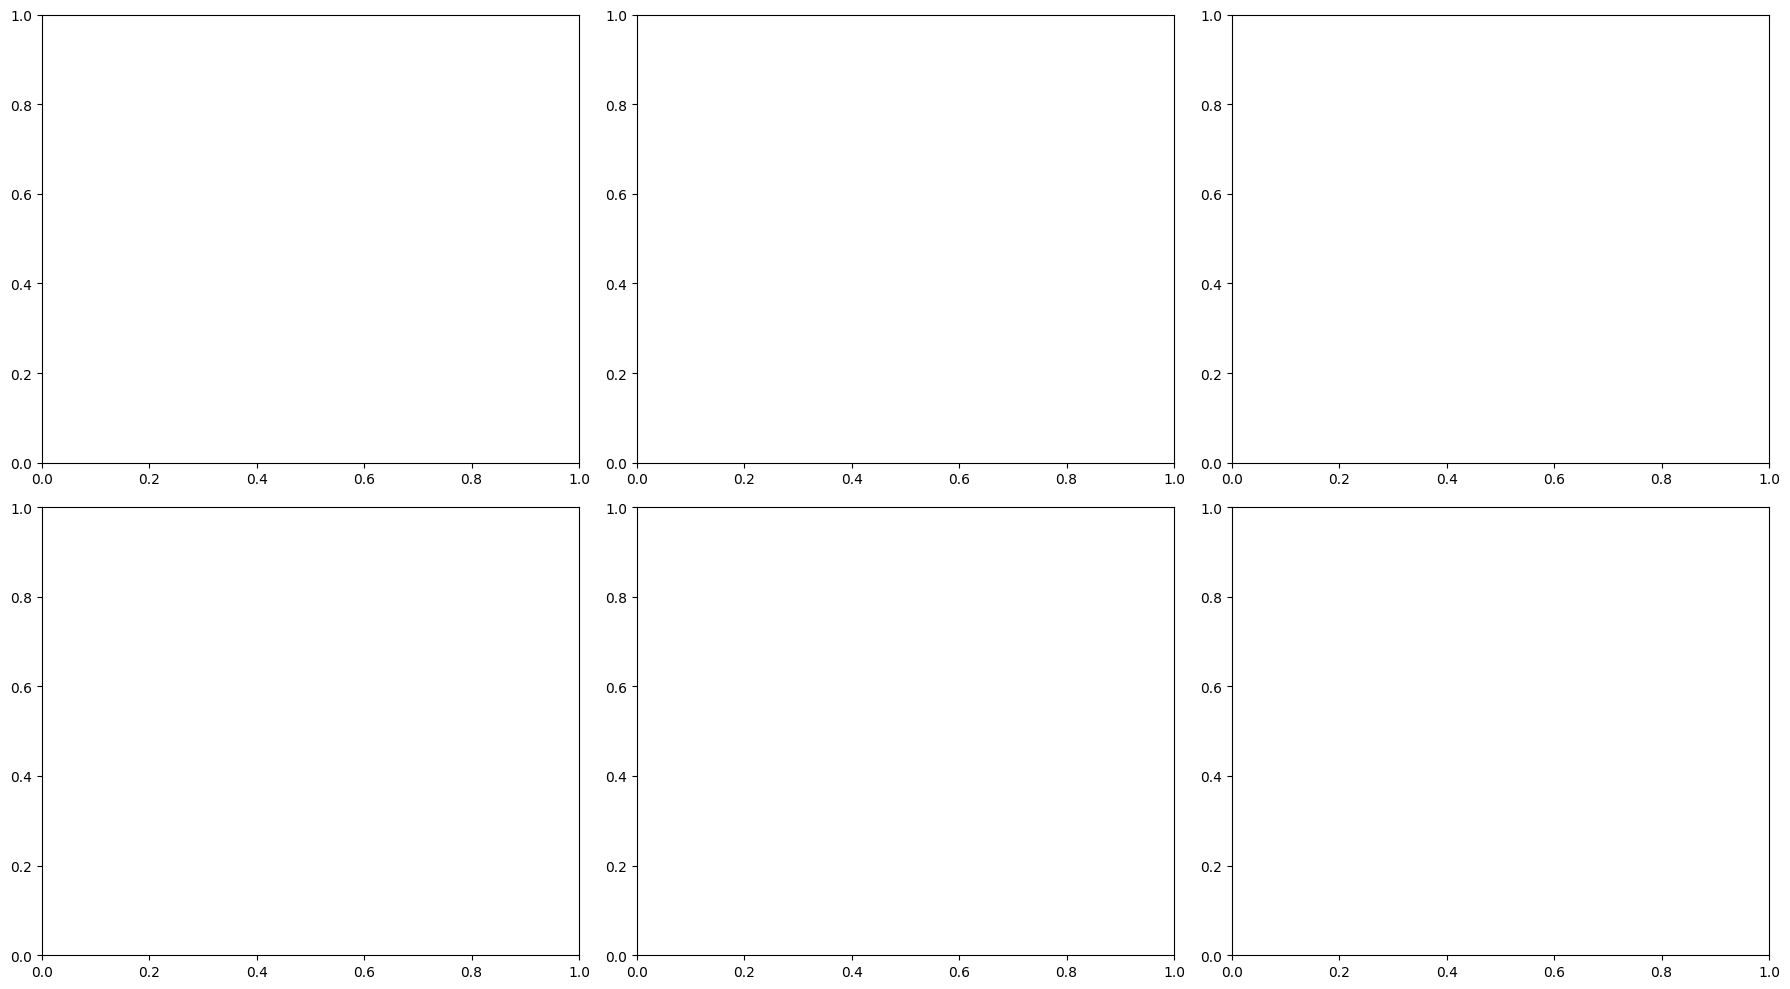

In [11]:
fig, axes = plt.subplots(2,3,figsize=(18,10))

cat_cols = [col for col in df_train.columns if df_train[col].dtype=="O"]
for ax, col in zip(axes.flatten(),cat_cols):
    df_train.groupby(col)['loan_paid_back'].mean().sort_values().plot(kind='barh',ax=ax)
    ax.set_title(f"Loan Paid Back Rate : {col}")
    ax.set_xlabel('Pay Rate')

plt.tight_layout()
plt.show()

In [12]:
numeric_cols = [col for col in df_train.columns if df_train[col].dtype!="O"]


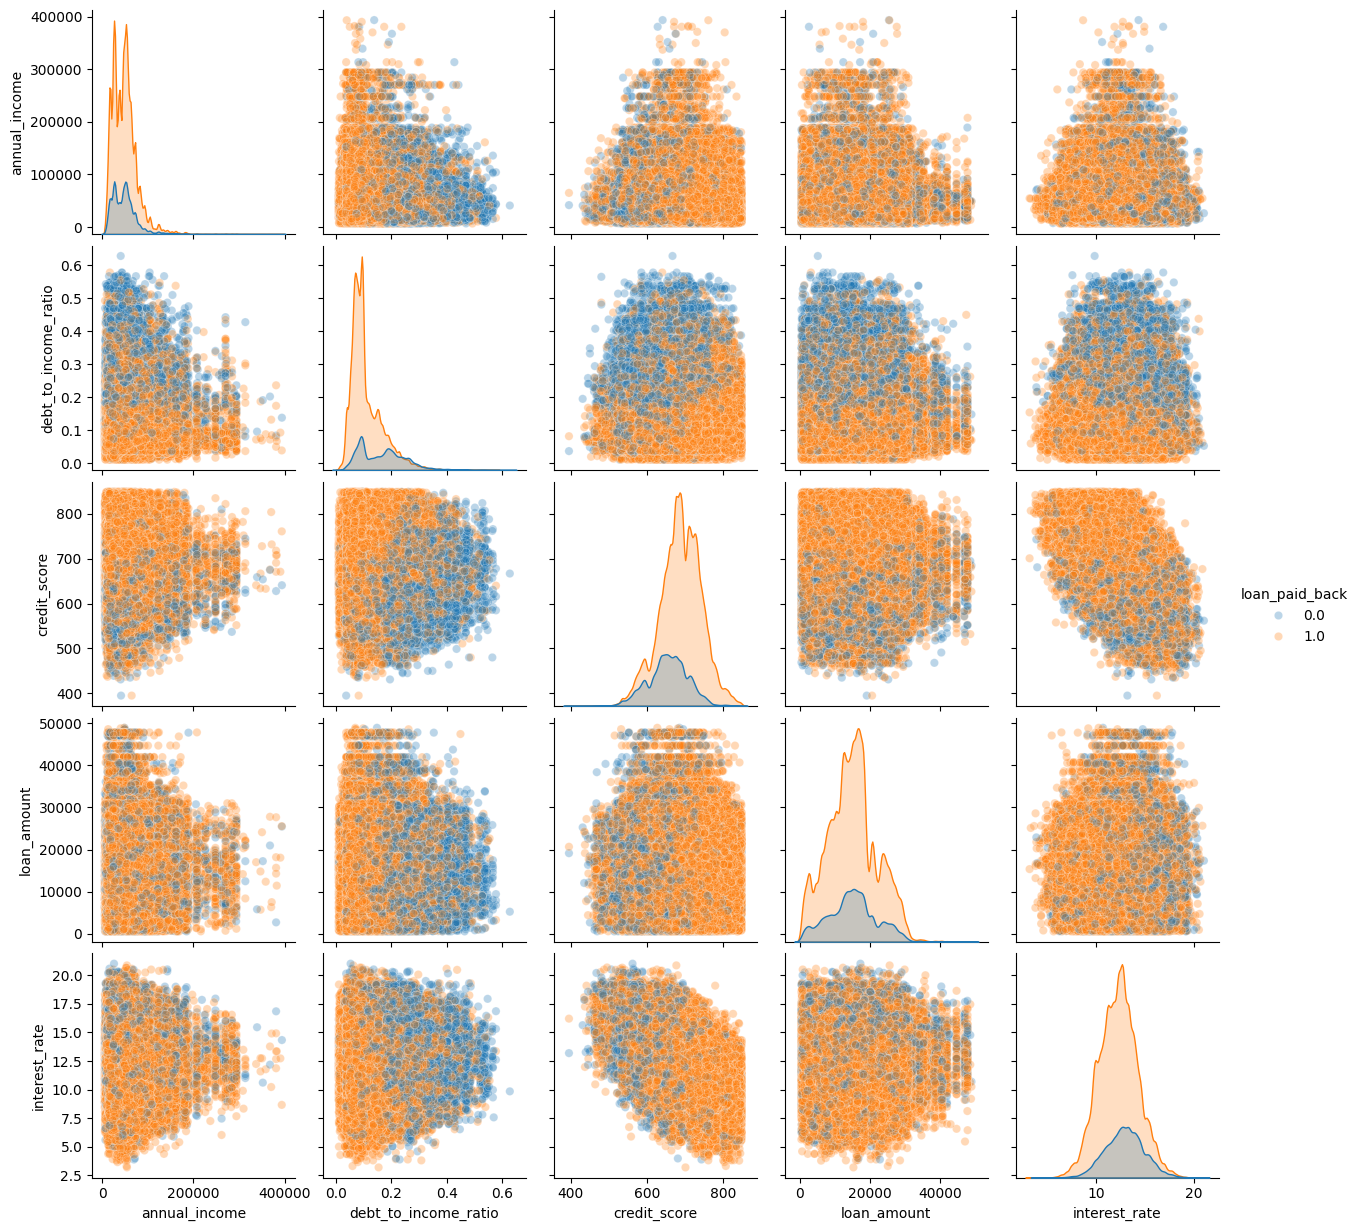

In [13]:
sns.pairplot(df_train[numeric_cols],hue='loan_paid_back',diag_kind='kde',plot_kws={'alpha':0.3})

In [14]:
def plot_all_hist(df_train,title_prefix = ""):
    num_cols = df_train.select_dtypes(include=["int64","float"]).columns
    n_cols=3
    n_rows = math.ceil(len(numeric_cols)/n_cols)
    plt.figure(figsize=(5*n_cols,5*n_rows))
    for i, col in enumerate(numeric_cols,1):
        plt.subplot(n_rows,n_cols,i)
        sns.histplot(df_train[col],kde=True,bins=40,)
        plt.title(f"{title_prefix} {col}")

    plt.tight_layout()
    plt.show()


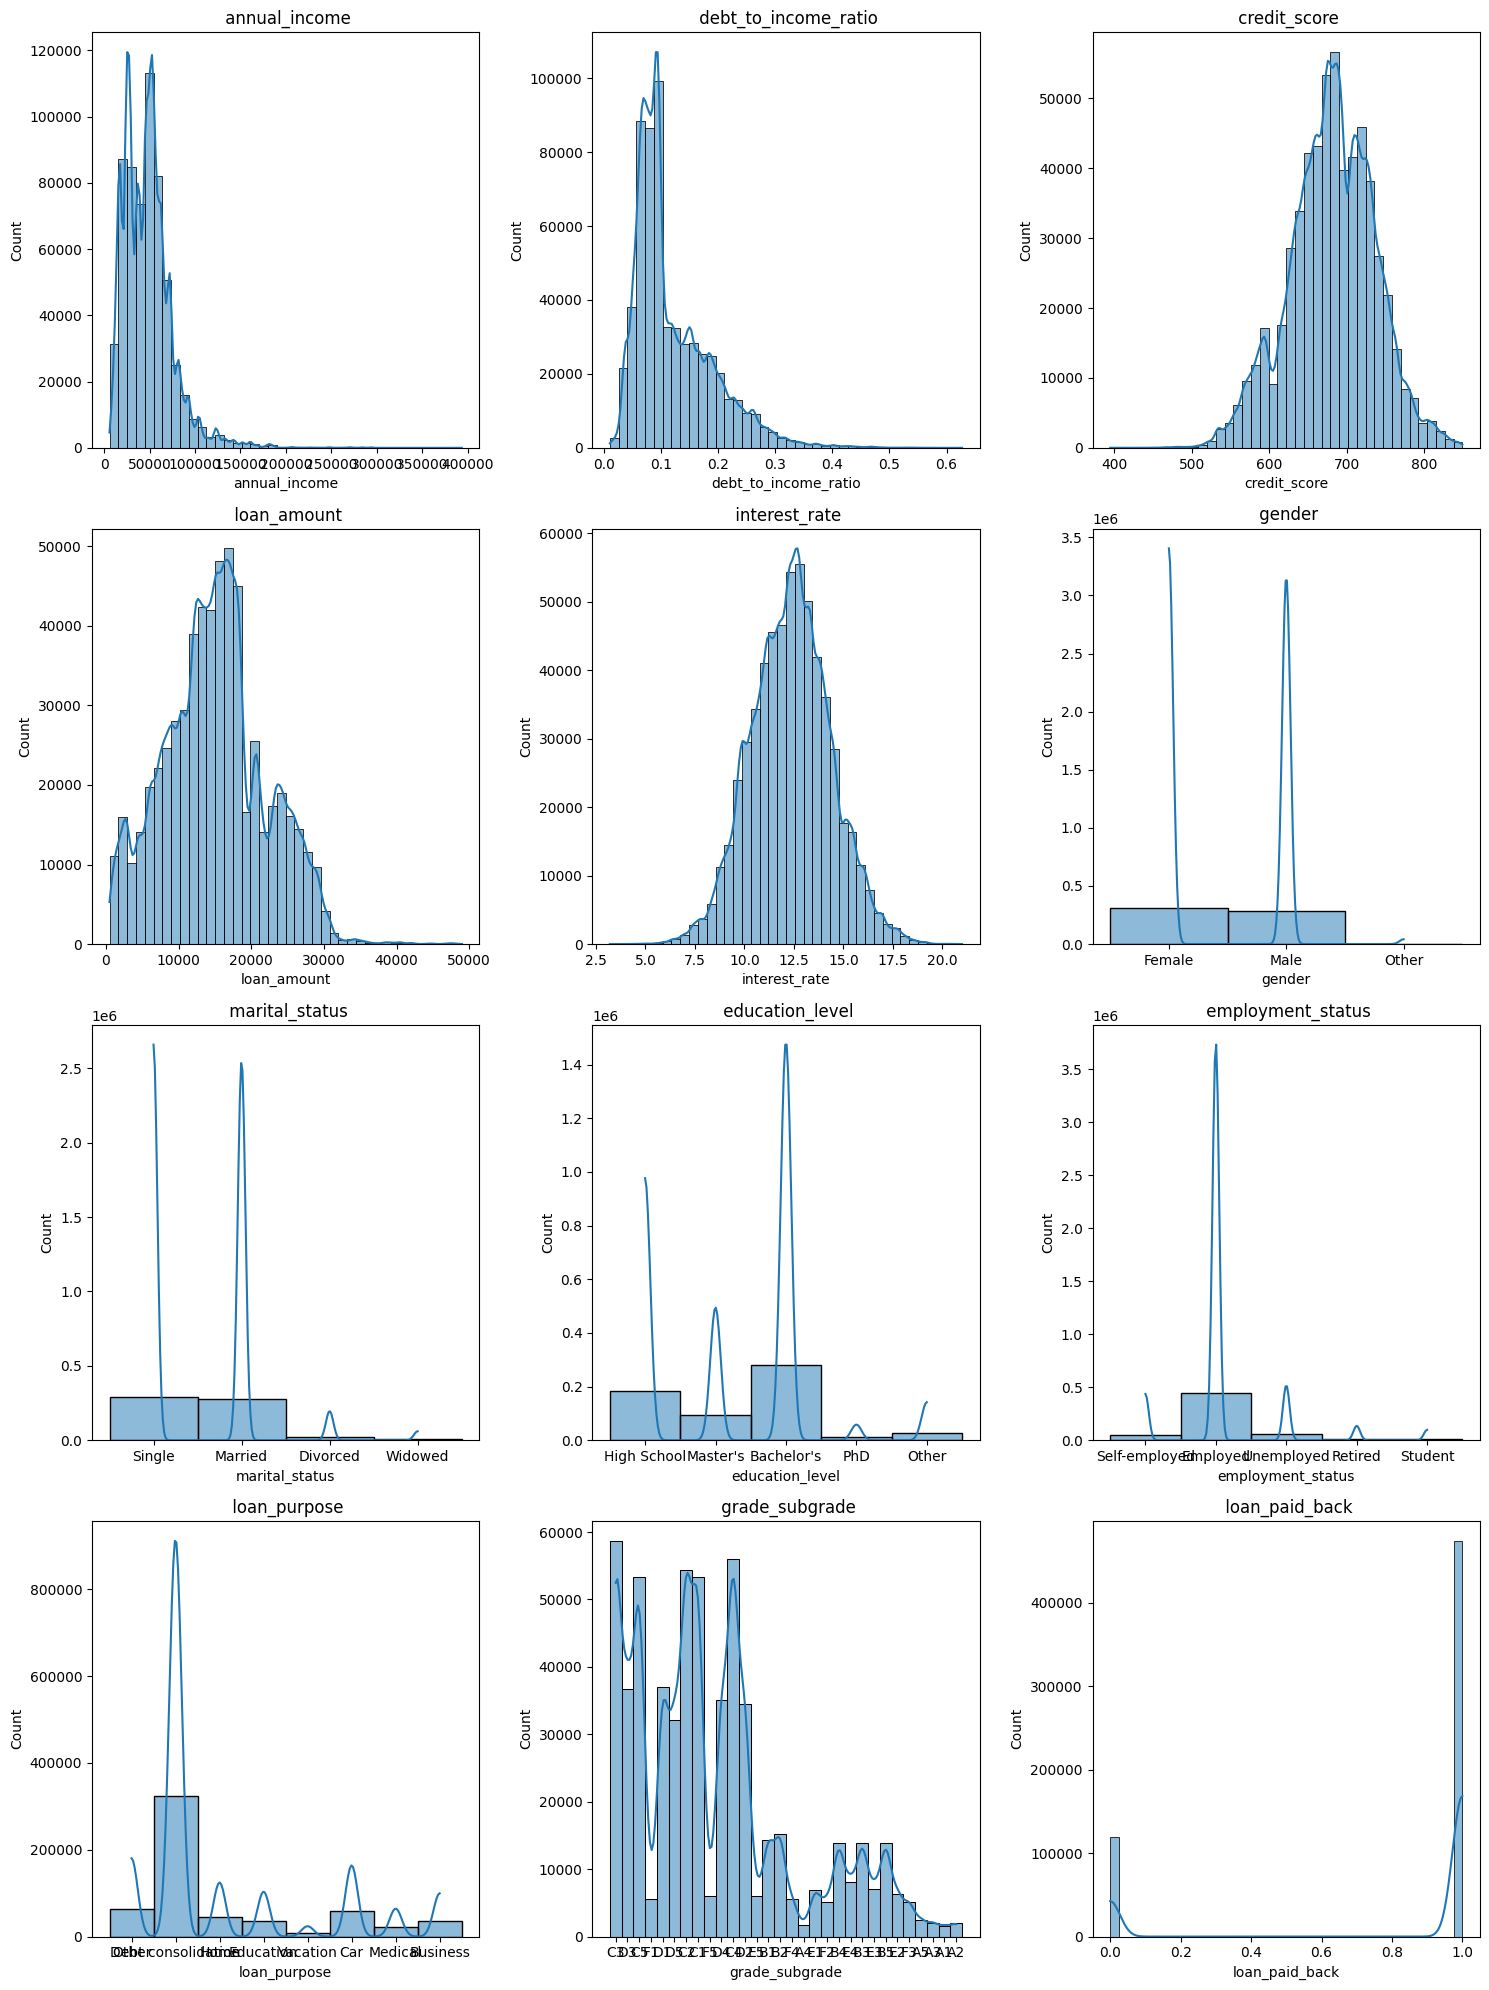

In [15]:
plot_all_hist(df_train)

In [16]:
def show_value_counts(df, cols):
    for col in cols:
        print(f"\n{col}")
        print('------------------')
        print(df[col].value_counts()
             )

In [17]:
show_value_counts(df_train,cat_cols)

## 3.FEATURE ENGINEERING

In [18]:
cols_to_onehot = ['gender','marital_status','employment_status']

In [19]:
df_train = pd.get_dummies(df_train,columns=cols_to_onehot,drop_first=True,dtype=int)
df_test = pd.get_dummies(df_test,columns=cols_to_onehot,drop_first=True,dtype=int)

In [20]:
df_train['education_level'].value_counts()

education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64

In [21]:
education_order = {
    'Other':0,
    'High School':1,
    'Bachelor\'s': 2,
    'Master\'s': 3,
    'PhD': 4
}

df_train['education_level'] = df_train['education_level'].map(education_order)
df_test['education_level'] = df_test['education_level'].map(education_order)

In [22]:
grade_order = sorted(df_train['grade_subgrade'].unique(),
                     key=lambda x: (x[0], int(x[1])))
grade_mapping = {grade: idx for idx, grade in enumerate(grade_order)}
df_train['grade_subgrade'] = df_train['grade_subgrade'].map(grade_mapping)


grade_order = sorted(df_test['grade_subgrade'].unique(),
                     key=lambda x: (x[0], int(x[1])))
grade_mapping = {grade: idx for idx, grade in enumerate(grade_order)}
df_test['grade_subgrade'] = df_test['grade_subgrade'].map(grade_mapping)

In [23]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 254569 entries, 0 to 254568
Data columns (total 17 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   annual_income                    254569 non-null  float64
 1   debt_to_income_ratio             254569 non-null  float64
 2   credit_score                     254569 non-null  int64  
 3   loan_amount                      254569 non-null  float64
 4   interest_rate                    254569 non-null  float64
 5   education_level                  254569 non-null  int64  
 6   loan_purpose                     254569 non-null  str    
 7   grade_subgrade                   254569 non-null  int64  
 8   gender_Male                      254569 non-null  int64  
 9   gender_Other                     254569 non-null  int64  
 10  marital_status_Married           254569 non-null  int64  
 11  marital_status_Single            254569 non-null  int64  
 12  marital_statu

In [24]:
freq_map_tr = df_train['loan_purpose'].value_counts(normalize=True)
freq_map_test = df_test['loan_purpose'].value_counts(normalize=True)

In [25]:
df_train['loan_purpose'] = df_train['loan_purpose'].map(freq_map_tr)
df_test['loan_purpose'] = df_test['loan_purpose'].map(freq_map_test)

In [26]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   annual_income                    593994 non-null  float64
 1   debt_to_income_ratio             593994 non-null  float64
 2   credit_score                     593994 non-null  int64  
 3   loan_amount                      593994 non-null  float64
 4   interest_rate                    593994 non-null  float64
 5   education_level                  593994 non-null  int64  
 6   loan_purpose                     593994 non-null  float64
 7   grade_subgrade                   593994 non-null  int64  
 8   loan_paid_back                   593994 non-null  float64
 9   gender_Male                      593994 non-null  int64  
 10  gender_Other                     593994 non-null  int64  
 11  marital_status_Married           593994 non-null  int64  
 12  marital_statu

In [27]:
df_train['loan_to_income'] = df_train['loan_amount'] / (df_train['annual_income'] + 1)
df_test['loan_to_income']  = df_test['loan_amount'] / (df_test['annual_income'] + 1)


In [28]:
df_train['risk_score'] = df_train['debt_to_income_ratio'] * df_train['interest_rate']
df_test['risk_score']  = df_test['debt_to_income_ratio'] * df_test['interest_rate']

In [29]:
df_train['log_income'] = np.log1p(df_train['annual_income'])
df_test['log_income']  = np.log1p(df_test['annual_income'])


In [30]:
df_train['grade_main'] = df_train['grade_subgrade'] // 5
df_test['grade_main']  = df_test['grade_subgrade'] // 5

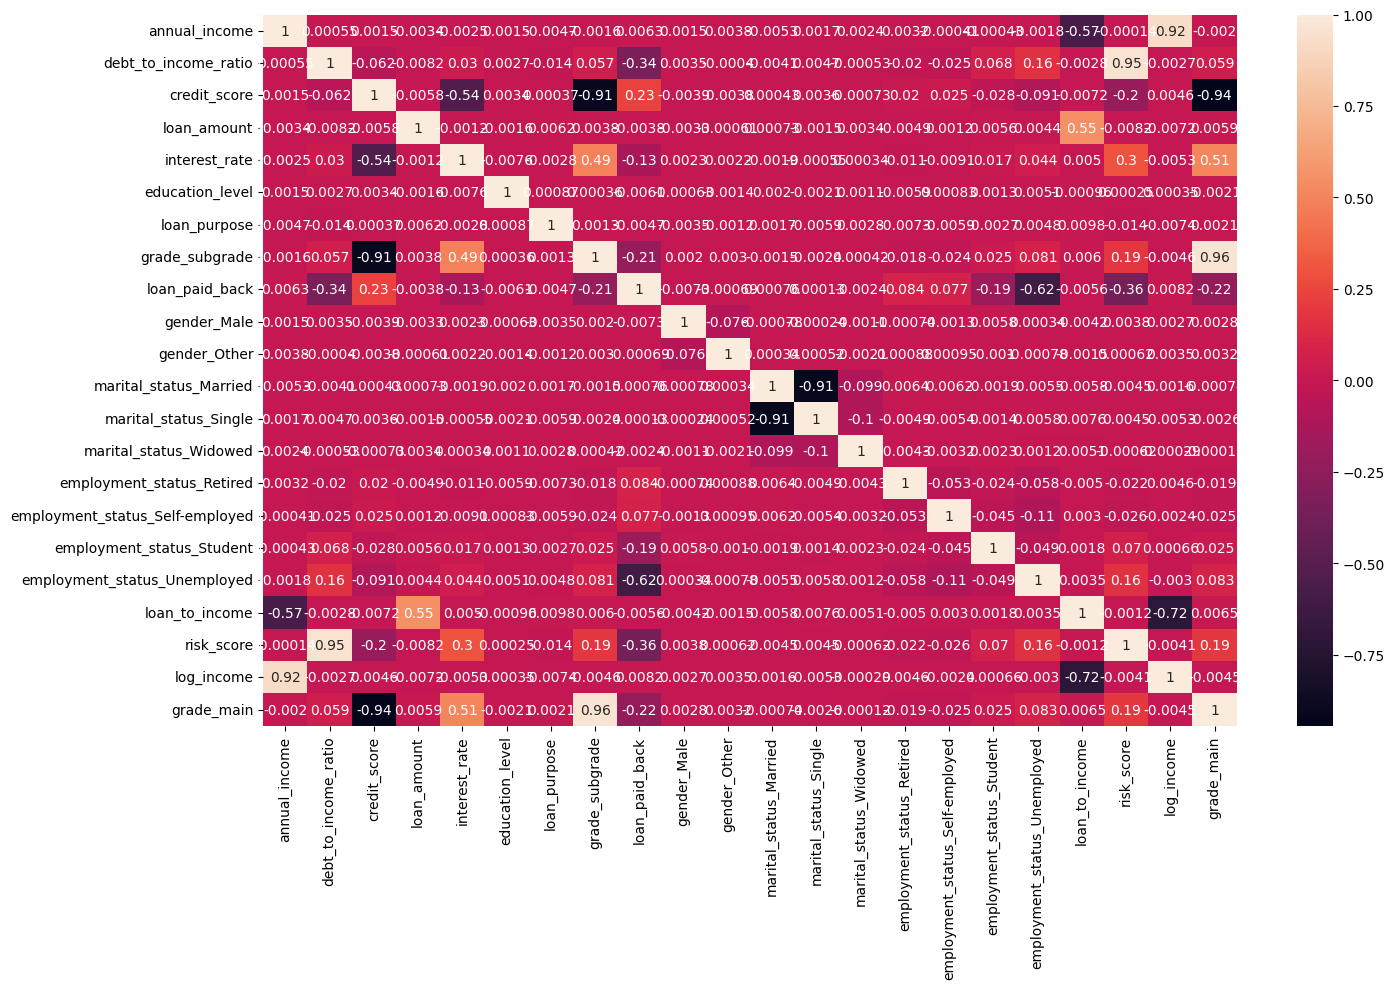

In [31]:
plt.figure(figsize=(15,10))
sns.heatmap(df_train.corr(),annot=True)
plt.tight_layout()
plt.show()

## 4.FEATURE IMPORTANCES

In [32]:
corr = df_train.corr(numeric_only=True)

target_corr = corr['loan_paid_back'].sort_values(ascending=False)

print(target_corr)

loan_paid_back                     1.000000
credit_score                       0.234560
employment_status_Retired          0.083526
employment_status_Self-employed    0.077374
log_income                         0.008248
annual_income                      0.006326
marital_status_Married             0.000758
marital_status_Single              0.000131
gender_Other                      -0.000691
marital_status_Widowed            -0.002372
loan_amount                       -0.003762
loan_purpose                      -0.004706
loan_to_income                    -0.005611
education_level                   -0.006080
gender_Male                       -0.007326
interest_rate                     -0.131184
employment_status_Student         -0.191178
grade_subgrade                    -0.212376
grade_main                        -0.218781
debt_to_income_ratio              -0.335680
risk_score                        -0.355044
employment_status_Unemployed      -0.616839
Name: loan_paid_back, dtype: flo

In [33]:
X = df_train.drop('loan_paid_back',axis=1)
y = df_train['loan_paid_back']

## 5.TRAINING MODELS

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [37]:
!pip install catboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


models_classification = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Extra Trees': ExtraTreesClassifier(),

    'KNN Classifier': KNeighborsClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),

    'XGBoost': XGBClassifier(),
    'LightGBM': LGBMClassifier(),
    'CatBoost': CatBoostClassifier()

}

In [39]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score
def evaluate_scores(true,predicted):
    accuracy = accuracy_score(true,predicted)
    report  = classification_report(true,predicted)
    matrix = confusion_matrix(true,predicted)
    roc = roc_auc_score(true,predicted)


    return accuracy,report,matrix,roc


In [40]:
for i in range(len(list(models_classification))):
    model = list(models_classification.values())[i]
    model.fit(X_train_scaled,y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_accuracy,train_report,train_matrix,train_roc = evaluate_scores(y_train,y_train_pred)
    test_accuracy,test_report,test_matrix,test_roc = evaluate_scores(y_test,y_test_pred)

    print(list(models_classification.keys())[i])
    print('model performance for Training Set')
    print('Root accuracy: ',train_accuracy)
    print(train_report)
    print(train_matrix)
    print('Root roc: ',train_roc)

    print('-------------------------------')
    print('model performance for Test Set')
    print('Test accuracy: ',test_accuracy)
    print(test_report)
    print(test_matrix)
    print('Test Roc: ',test_roc)

    print('******************************')
    print('******************************')

Logistic Regression
model performance for Training Set
Root accuracy:  0.8998232301975734
              precision    recall  f1-score   support

         0.0       0.85      0.61      0.71     83403
         1.0       0.91      0.97      0.94    332392

    accuracy                           0.90    415795
   macro avg       0.88      0.79      0.82    415795
weighted avg       0.90      0.90      0.89    415795

[[ 50536  32867]
 [  8786 323606]]
Root roc:  0.7897464002675774
-------------------------------
model performance for Test Set
Test accuracy:  0.8995841727506888
              precision    recall  f1-score   support

         0.0       0.86      0.61      0.71     36097
         1.0       0.91      0.97      0.94    142102

    accuracy                           0.90    178199
   macro avg       0.88      0.79      0.82    178199
weighted avg       0.90      0.90      0.89    178199

[[ 21861  14236]
 [  3658 138444]]
Test Roc:  0.7899380614110803
****************************

/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
model performance for Training Set
Root accuracy:  0.9056025204728292
              precision    recall  f1-score   support

         0.0       0.90      0.60      0.72     83403
         1.0       0.91      0.98      0.94    332392

    accuracy                           0.91    415795
   macro avg       0.90      0.79      0.83    415795
weighted avg       0.90      0.91      0.90    415795

[[ 49991  33412]
 [  5838 326554]]
Root roc:  0.7909136547973117
-------------------------------
model performance for Test Set
Test accuracy:  0.903719998428723
              precision    recall  f1-score   support

         0.0       0.89      0.60      0.71     36097
         1.0       0.91      0.98      0.94    142102

    accuracy                           0.90    178199
   macro avg       0.90      0.79      0.83    178199
weighted avg       0.90      0.90      0.90    178199

[[ 21502  14595]
 [  2562 139540]]
Test Roc:  0.7888217338476251
******************************
*********

In [41]:
cols_to_drop = [
    "marital_status_Married", "marital_status_Single", "marital_status_Widowed",
    "gender_Other", "gender_Male", "loan_purpose", "education_level",
    "annual_income", "log_income", "loan_amount", "loan_to_income"
]

In [42]:
X.drop(cols_to_drop,axis=1,inplace=True)

In [43]:
X

,debt_to_income_ratio,credit_score,interest_rate,grade_subgrade,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,risk_score,grade_main
0,0.084,736,13.67,12,0,1,0,0,1.14828,2
1,0.166,636,12.92,17,0,0,0,0,2.14472,3
2,0.097,694,9.76,14,0,0,0,0,0.94672,2
3,0.065,533,16.10,25,0,0,0,0,1.04650,5
4,0.053,665,10.21,15,0,0,0,0,0.54113,3
...,...,...,...,...,...,...,...,...,...,...
593989,0.152,703,10.92,12,0,0,0,0,1.65984,2
593990,0.105,559,14.62,29,0,0,0,0,1.53510,5
593991,0.072,675,14.13,10,0,0,0,0,1.01736,2
593992,0.067,740,9.87,6,0,0,0,0,0.66129,1


In [44]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


models_classification = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Extra Trees': ExtraTreesClassifier(),

    'KNN Classifier': KNeighborsClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),

    'XGBoost': XGBClassifier(),
    'LightGBM': LGBMClassifier(verbose=0),
    'CatBoost': CatBoostClassifier(verbose=0)

}

In [47]:
for i in range(len(list(models_classification))):
    model = list(models_classification.values())[i]
    model.fit(X_train_scaled,y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_accuracy,train_report,train_matrix,train_roc = evaluate_scores(y_train,y_train_pred)
    test_accuracy,test_report,test_matrix,test_roc = evaluate_scores(y_test,y_test_pred)

    print(list(models_classification.keys())[i])
    print('model performance for Training Set')
    print('Root accuracy: ',train_accuracy)
    print(train_report)
    print(train_matrix)
    print('Root roc: ',train_roc)

    print('-------------------------------')
    print('model performance for Test Set')
    print('Test accuracy: ',test_accuracy)
    print(test_report)
    print(test_matrix)
    print('Test Roc: ',test_roc)

    print('******************************')
    print('******************************')

Logistic Regression
model performance for Training Set
Root accuracy:  0.8998328503228754
              precision    recall  f1-score   support

         0.0       0.85      0.61      0.71     83403
         1.0       0.91      0.97      0.94    332392

    accuracy                           0.90    415795
   macro avg       0.88      0.79      0.82    415795
weighted avg       0.90      0.90      0.89    415795

[[ 50526  32877]
 [  8772 323620]]
Root roc:  0.7897075098576275
-------------------------------
model performance for Test Set
Test accuracy:  0.8996459014921521
              precision    recall  f1-score   support

         0.0       0.86      0.61      0.71     36097
         1.0       0.91      0.97      0.94    142102

    accuracy                           0.90    178199
   macro avg       0.88      0.79      0.82    178199
weighted avg       0.90      0.90      0.89    178199

[[ 21875  14222]
 [  3661 138441]]
Test Roc:  0.7901214275457029
****************************

/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
model performance for Training Set
Root accuracy:  0.9053475871523227
              precision    recall  f1-score   support

         0.0       0.89      0.60      0.72     83403
         1.0       0.91      0.98      0.94    332392

    accuracy                           0.91    415795
   macro avg       0.90      0.79      0.83    415795
weighted avg       0.90      0.91      0.90    415795

[[ 50077  33326]
 [  6030 326362]]
Root roc:  0.7911404081663433
-------------------------------
model performance for Test Set
Test accuracy:  0.9039500782832676
              precision    recall  f1-score   support

         0.0       0.89      0.60      0.72     36097
         1.0       0.91      0.98      0.94    142102

    accuracy                           0.90    178199
   macro avg       0.90      0.79      0.83    178199
weighted avg       0.90      0.90      0.90    178199

[[ 21620  14477]
 [  2639 139463]]
Test Roc:  0.790185286560532
******************************
*********

## 6.HYPERPARAMETER TUNING WITH STRATIFIEDKFOLD

In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import gc
cols_to_drop = [
    "marital_status_Married", "marital_status_Single", "marital_status_Widowed",
    "gender_Other", "gender_Male", "loan_purpose", "education_level",
    "annual_income", "log_income", "loan_amount", "loan_to_income"
]


X_test_final = df_test.drop(cols_to_drop, axis=1)

for df in [X, X_test_final]:
    df['risk_factor'] = df['interest_rate'] * (df['grade_subgrade'] + 1)
    df['credit_efficiency'] = df['credit_score'] / (df['interest_rate'] + 1)
    df['dti_grade'] = df['debt_to_income_ratio'] * (df['grade_main'] + 1)

lgbm_params = {
    'colsample_bytree': 0.619881270749716, 'learning_rate': 0.2555209060957825,
    'max_depth': 3, 'n_estimators': 800, 'num_leaves': 129,
    'reg_alpha': 3.1816630909294767, 'reg_lambda': 1.2523090930279208,
    'subsample': 0.7949354237802719, 'objective': 'binary', 'metric': 'auc',
    'random_state': 42, 'n_jobs': -1, 'verbose': -1
}

cat_params = {
    'iterations': 1000, 'learning_rate': 0.03, 'depth': 6,
    'l2_leaf_reg': 3, 'random_seed': 42, 'verbose': 0
}

n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test_final))


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test_final)


    model_lgb = LGBMClassifier(**lgbm_params)
    model_cat = CatBoostClassifier(**cat_params)

    model_lgb.fit(X_train_s, y_train)
    model_cat.fit(X_train_s, y_train)


    lgb_val = model_lgb.predict_proba(X_val_s)[:, 1]
    cat_val = model_cat.predict_proba(X_val_s)[:, 1]

    lgb_test = model_lgb.predict_proba(X_test_s)[:, 1]
    cat_test = model_cat.predict_proba(X_test_s)[:, 1]


    fold_val_preds = np.sqrt((lgb_val**2 * 0.70) + (cat_val**2 * 0.30))
    fold_test_preds = np.sqrt((lgb_test**2 * 0.70) + (cat_test**2 * 0.30))

    oof_preds[val_idx] = fold_val_preds
    test_preds += fold_test_preds / n_splits

    print(f"Fold {fold} AUC: {roc_auc_score(y_val, fold_val_preds):.5f}")

    del model_lgb, model_cat; gc.collect()

overall_auc = roc_auc_score(y, oof_preds)
print(f"\n Final Optimized OOF AUC: {overall_auc:.6f}")

submission = pd.DataFrame({
    'id': df_test_id['id'],
    'loan_paid_back': test_preds
})
submission.to_csv('submission_0926_target.csv', index=False)

/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1 AUC: 0.92420


/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2 AUC: 0.92187


/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

Fold 8 AUC: 0.92297


/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 9 AUC: 0.92091


/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 10 AUC: 0.92207

 Final Optimized OOF AUC: 0.922074


## 7. AUDIT: SHAP & LIME on the deployed ensemble

The model under audit is the artifact that wrote `submission_0926_target.csv`: a 10-fold ensemble of LightGBM + CatBoost, blended per-fold with `sqrt(0.7 * lgb^2 + 0.3 * cat^2)` and averaged across folds.

We reconstruct that ensemble deterministically. The original training pipeline uses `random_state=42` for the K-fold split and both classifiers, so refitting with identical splits/seeds/params produces models functionally identical to the ones that wrote the submission. (Threading via `n_jobs=-1` may introduce tiny numerical noise but does not change behavior.) This is auditing the deployed artifact, not a stand-in.

Two complementary explanations:

- **SHAP**: exact Shapley values via `TreeExplainer` on each of the 20 fold models, aggregated *per model type* (LGBM avg, CatBoost avg). Caveat: because the L2 blend `sqrt(0.7 * lgb^2 + 0.3 * cat^2)` is non-linear, per-component SHAPs do not sum to the ensemble's SHAP. They show what each half of the blend is doing, which is what we need for an audit.
- **LIME**: model-agnostic, so it explains the *full* ensemble's `predict_proba` directly (no caveats).

Audit question: does the model lean on potentially biased proxies (employment status, lender-assigned risk grade)?

In [57]:
!pip install shap lime


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [58]:
# Reconstruct the deployed 10-fold ensemble. Same StratifiedKFold(random_state=42),
# same LGBM and CatBoost params with random_state=42 / random_seed=42, same per-fold
# StandardScaler, so refit produces models functionally identical to the ones that
# wrote submission_0926_target.csv. We are not training a new model; we are
# rehydrating the deployed one for explanation.

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

fold_lgbs    = []
fold_cats    = []
fold_scalers = []

skf_audit = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (train_idx, _) in enumerate(skf_audit.split(X, y), 1):
    X_tr = X.iloc[train_idx]
    y_tr = y.iloc[train_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)

    m_lgb = LGBMClassifier(**lgbm_params)
    m_cat = CatBoostClassifier(**cat_params)
    m_lgb.fit(X_tr_s, y_tr)
    m_cat.fit(X_tr_s, y_tr)

    fold_lgbs.append(m_lgb)
    fold_cats.append(m_cat)
    fold_scalers.append(scaler)
    print(f"Refit fold {fold}/{n_splits}")

# Faithful ensemble inference: replays the exact L2 blend from cell 6 (section 6).
def predict_proba_ensemble(X_input):
    if not isinstance(X_input, pd.DataFrame):
        X_input = pd.DataFrame(X_input, columns=X.columns)
    p1 = np.zeros(len(X_input))
    for sc, m_lgb, m_cat in zip(fold_scalers, fold_lgbs, fold_cats):
        X_s = sc.transform(X_input)
        lgb_p = m_lgb.predict_proba(X_s)[:, 1]
        cat_p = m_cat.predict_proba(X_s)[:, 1]
        p1 += np.sqrt(0.70 * lgb_p**2 + 0.30 * cat_p**2) / n_splits
    return np.column_stack([1.0 - p1, p1])

print(f"\nReconstructed: {len(fold_lgbs)} LGBM + {len(fold_cats)} CatBoost models, "
      f"{len(fold_scalers)} scalers.")

Refit fold 1/10
Refit fold 2/10
Refit fold 3/10
Refit fold 4/10
Refit fold 5/10
Refit fold 6/10
Refit fold 7/10
Refit fold 8/10
Refit fold 9/10
Refit fold 10/10

Reconstructed: 10 LGBM + 10 CatBoost models, 10 scalers.


### 7.1 Global SHAP - both halves of the ensemble

Each fold's LGBM and CatBoost are explained with `TreeExplainer`. We feed each fold's per-fold-scaled sample into its own explainer, then average SHAP contributions across the 10 folds, separately for LGBM and CatBoost. This gives two views: how the 70%-weight LGBM half drives predictions, and how the 30%-weight CatBoost half does.

SHAP units are log-odds. Positive = pushes toward `loan_paid_back=1`.

Aggregated SHAP across 10 folds. LGBM shape=(2000, 13), CatBoost shape=(2000, 13)

=== LGBM (70% blend weight) ===


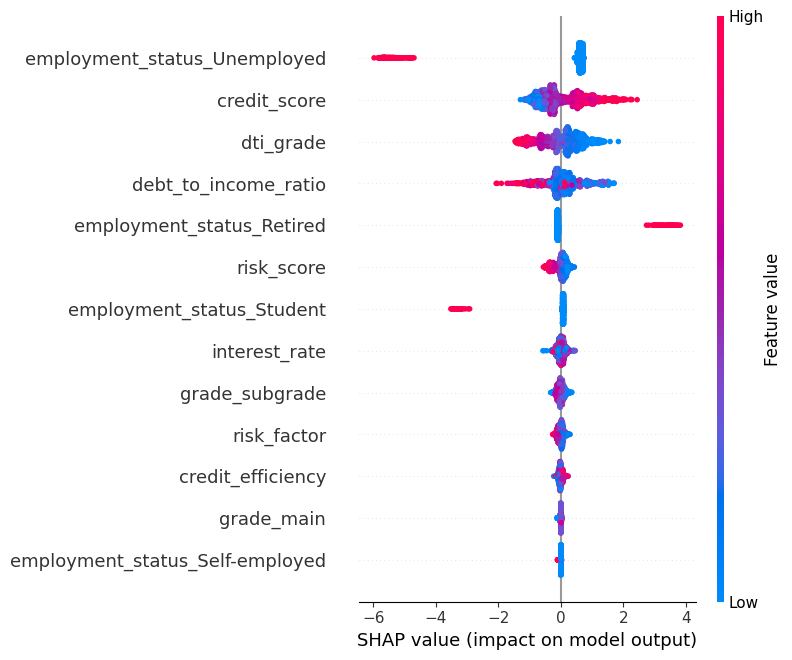

=== CatBoost (30% blend weight) ===


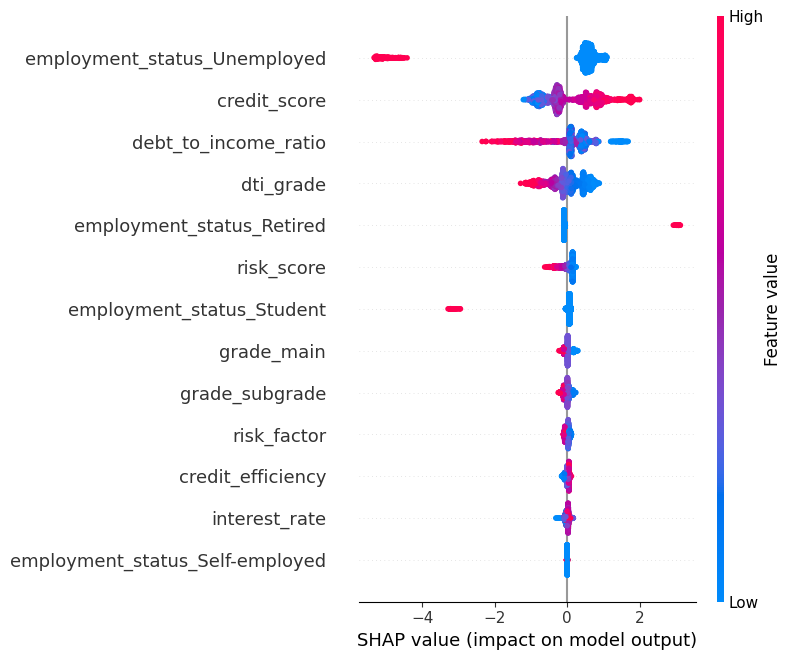

In [59]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*LightGBM binary classifier with TreeExplainer.*")
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

import shap

# Sample for plotting speed; SHAP is exact on tree models, so 2k rows is plenty
# for global patterns and keeps the 10-fold loop fast.
sample_idx = np.random.RandomState(42).choice(len(X), size=2000, replace=False)
X_sample = X.iloc[sample_idx].reset_index(drop=True)

sv_lgb = np.zeros((len(X_sample), X.shape[1]))
sv_cat = np.zeros((len(X_sample), X.shape[1]))

for fold_i, (sc, m_lgb, m_cat) in enumerate(zip(fold_scalers, fold_lgbs, fold_cats), 1):
    X_s = sc.transform(X_sample)

    s_lgb = shap.TreeExplainer(m_lgb).shap_values(X_s)
    if isinstance(s_lgb, list):
        s_lgb = s_lgb[1]
    sv_lgb += s_lgb / n_splits

    s_cat = shap.TreeExplainer(m_cat).shap_values(X_s)
    if isinstance(s_cat, list):
        s_cat = s_cat[1]
    sv_cat += s_cat / n_splits

print(f"Aggregated SHAP across {n_splits} folds. LGBM shape={sv_lgb.shape}, CatBoost shape={sv_cat.shape}\n")

print("=== LGBM (70% blend weight) ===")
shap.summary_plot(sv_lgb, X_sample, show=True)

print("=== CatBoost (30% blend weight) ===")
shap.summary_plot(sv_cat, X_sample, show=True)

=== LGBM mean |SHAP| ===


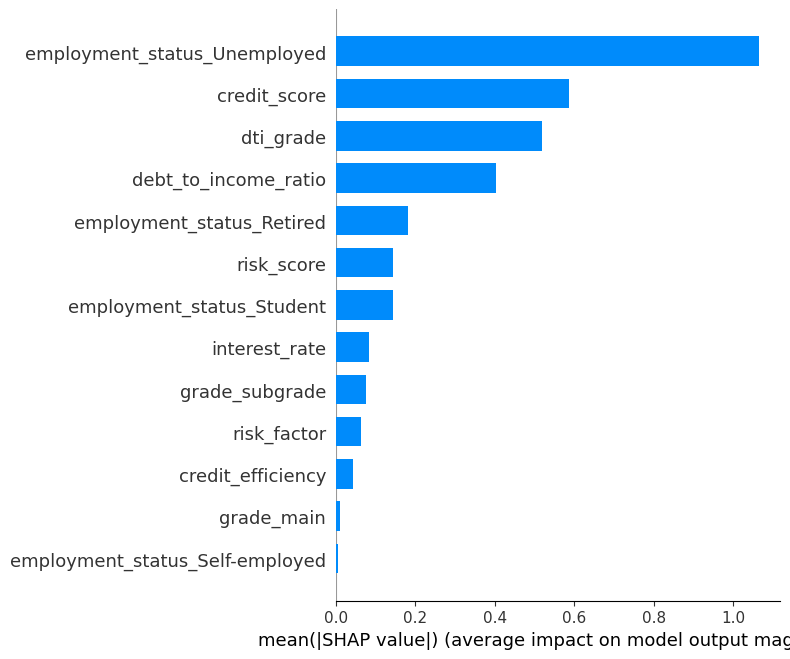

=== CatBoost mean |SHAP| ===


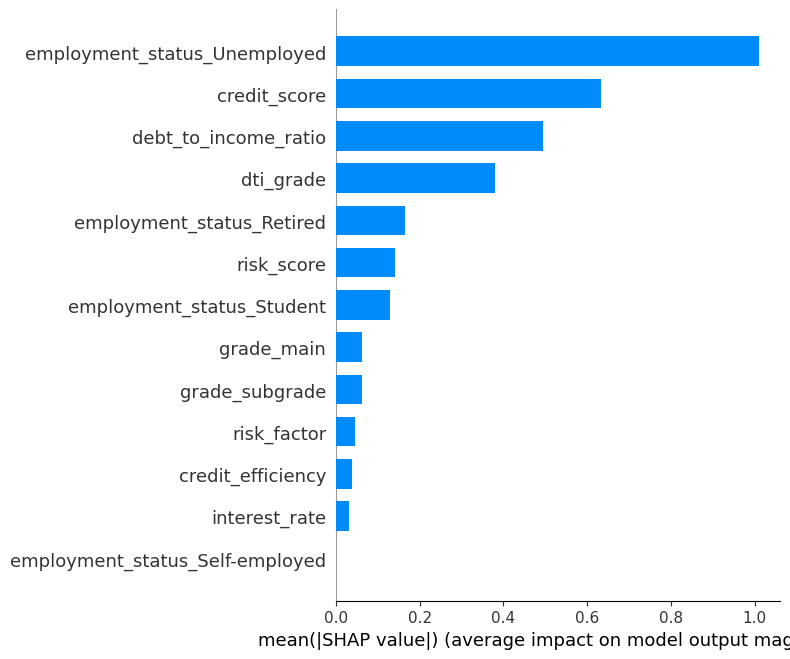

In [60]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*LightGBM binary classifier with TreeExplainer.*")
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

# Mean |SHAP|: pure feature-importance ranking for each ensemble half.
print("=== LGBM mean |SHAP| ===")
shap.summary_plot(sv_lgb, X_sample, plot_type="bar", show=True)

print("=== CatBoost mean |SHAP| ===")
shap.summary_plot(sv_cat, X_sample, plot_type="bar", show=True)

### 7.2 SHAP dependence - flagged audit features

Two features deserve scrutiny:

- **`employment_status_Unemployed`** had the strongest correlation with the target (-0.62 from the EDA). Employment status correlates with race, age, and disability, so heavy reliance here is a fairness concern.
- **`grade_subgrade`** is the lender's pre-existing risk grade. If we predict default *from* the lender's own grade, we inherit any bias baked into the original underwriting.

A dependence plot shows feature value on x-axis vs SHAP contribution on y-axis. SHAP auto-picks an interaction feature for the color.

=== LGBM dependence ===


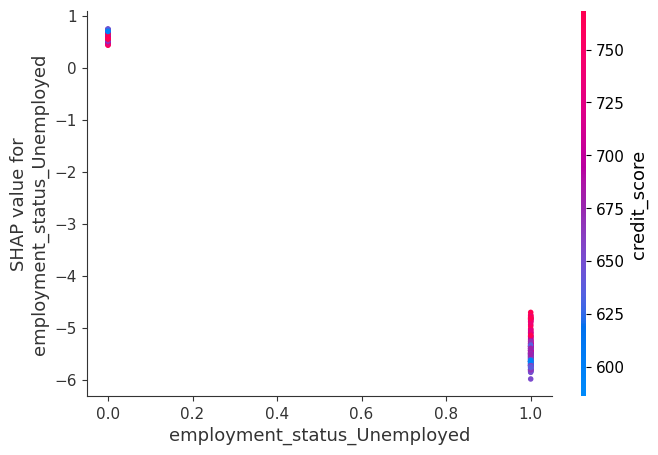

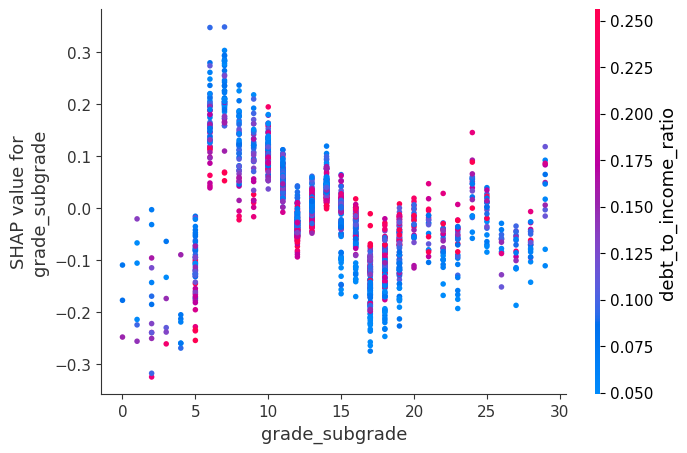

=== CatBoost dependence ===


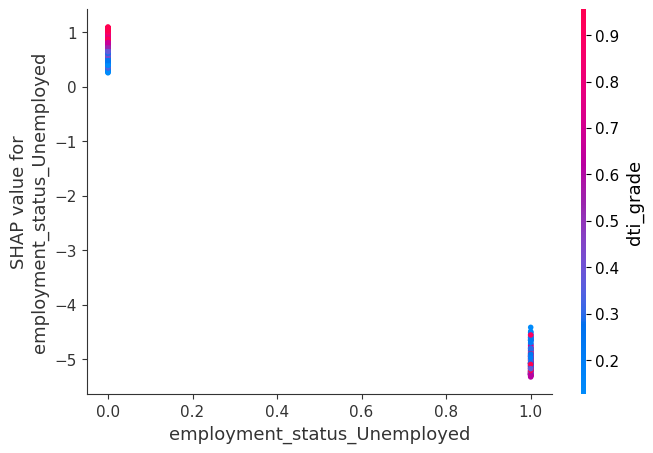

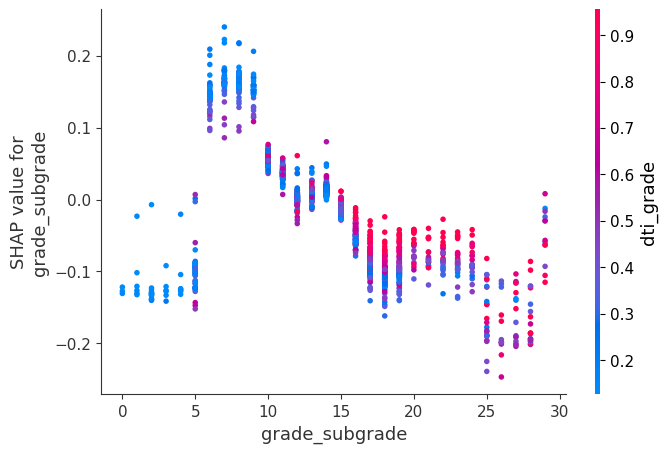

In [61]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*LightGBM binary classifier with TreeExplainer.*")
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

# Dependence plots for both audit-flagged features, in both ensemble halves.
print("=== LGBM dependence ===")
shap.dependence_plot("employment_status_Unemployed", sv_lgb, X_sample, show=True)
shap.dependence_plot("grade_subgrade", sv_lgb, X_sample, show=True)

print("=== CatBoost dependence ===")
shap.dependence_plot("employment_status_Unemployed", sv_cat, X_sample, show=True)
shap.dependence_plot("grade_subgrade", sv_cat, X_sample, show=True)

### 7.3 LIME - local explanations of the actual ensemble

LIME is model-agnostic, so it explains `predict_proba_ensemble` directly: the full L2-blended 10-fold ensemble, exactly as deployed. No per-component approximation needed.

We pick three representative training-set rows by their out-of-fold predicted probability: a confidently paid-back, a confidently default, and a borderline case near `p ~ 0.5`. Using OOF predictions (already computed in section 6) means the prediction for each row was made by the 9 folds that did *not* train on it, so we are inspecting how the ensemble generalizes to held-out individuals.

In [62]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X.values,
    feature_names=list(X.columns),
    class_names=['default', 'paid_back'],
    mode='classification',
    discretize_continuous=True,
    random_state=42,
)

# Pick three rows by OOF predicted probability: that is the held-out probability
# from the 9 folds that did not see each row, already computed in section 6.
idx_paid    = int(np.argmax(oof_preds))
idx_default = int(np.argmin(oof_preds))
idx_border  = int(np.argmin(np.abs(oof_preds - 0.5)))

cases = [
    ("high paid-back prob", idx_paid),
    ("high default prob",   idx_default),
    ("borderline (~0.5)",   idx_border),
]

for label, idx in cases:
    actual = int(y.iloc[idx])
    p_oof = oof_preds[idx]
    print(f"\n=== {label} | row {idx} | OOF p(paid_back) = {p_oof:.3f} | actual = {actual} ===")
    exp = lime_explainer.explain_instance(
        X.iloc[idx].values,
        predict_proba_ensemble,   # the actual deployed ensemble
        num_features=10,
    )
    for feat, weight in exp.as_list():
        sign = "+" if weight >= 0 else "-"
        print(f"  {sign}{abs(weight):.4f}  {feat}")


=== high paid-back prob | row 231848 | OOF p(paid_back) = 1.000 | actual = 1 ===
  +0.7430  employment_status_Unemployed <= 0.00
  +0.4414  employment_status_Student <= 0.00
  +0.1210  employment_status_Retired > 0.00
  +0.1071  credit_score > 719.00
  +0.0742  dti_grade <= 0.22
  +0.0506  debt_to_income_ratio <= 0.07
  +0.0156  risk_score <= 0.87
  +0.0088  credit_efficiency > 58.88
  +0.0066  employment_status_Self-employed <= 0.00
  +0.0055  risk_factor <= 135.12

=== high default prob | row 549670 | OOF p(paid_back) = 0.000 | actual = 0 ===
  -0.7592  employment_status_Unemployed > 0.00
  +0.4733  employment_status_Student <= 0.00
  -0.1311  employment_status_Retired <= 0.00
  -0.1073  debt_to_income_ratio > 0.16
  -0.0999  dti_grade > 0.53
  -0.0990  credit_score <= 646.00
  -0.0279  risk_score > 1.92
  -0.0149  risk_factor > 233.89
  -0.0088  credit_efficiency <= 44.77
  +0.0065  2.00 < grade_main <= 3.00

=== borderline (~0.5) | row 182290 | OOF p(paid_back) = 0.500 | actual = 